
# Secondary Goal Exploration

Given a time budget, how many tasks can be completed?

For each WorkCode:

1. Load engineered data
2. ~20% of days for testing and earlier days for training
3. Train XGBoost
4. Build actual test chunks that are about 30 min long:
   - all rows in a chunk must have the same WorkCode
   - no task may exceed 300s
   - if a bad row is encountered before the chunk reaches the budget, the partial chunk is discarded and a new chunk starts after the bad row
   - each actual chunk stops immediately after cumulative actual time reaches the budget, so the realized chunk time is typically just above 30 minutes
5. For each chunk, record the actual number of tasks completed
6. At prediction time, start from the chunk's first task, add predicted task times forward until the cumulative predicted time exceeds the budget
   - this predicted scan is allowed to peek into later actual chunks as long as the rows remain in the same valid same-WorkCode segment
7. Compare actual task count vs predicted task count using MAE

In [55]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH = Path("../data/processed")
WAREHOUSE = "OE"

WORKCODES = ["10", "20", "30"]
#WORKCODES = ["1", "2", "3", "4", "5", "6"]
MAX_TIME = 300                  
TEST_RATIO = 0.15               
TIME_BUDGET_SEC = 30 * 60      
RANDOM_STATE = 2026

In [56]:

def resolve_data_path(warehouse):
    fname = f"{warehouse.lower()}_detailed.parquet"
    return PATH / fname


def load_engineered_data(warehouse, workcode, max_time=300):
    """
    Load clean engineered data using feature_engineer.py

    Expected return from get_engineered_df:
        df, features, cat_cols
    """
    data_path = resolve_data_path(warehouse)

    d, features_all, cat_cols_all = get_engineered_df(
        file_path=data_path,
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )

    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"] = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)
    d["Time_Delta_sec"] = pd.to_numeric(d["Time_Delta_sec"], errors="coerce")
    d = d.dropna(subset=["Time_Delta_sec"]).copy()

    return d, features_all, cat_cols_all


def split_by_days(df, test_ratio=0.20):
    """
    Chronological split:
    training = earlier days
    testing  = last ~test_ratio of days
    """
    all_days = sorted(pd.Series(df["date"].dropna().unique()))
    n_days = len(all_days)
    n_test_days = max(1, int(np.ceil(n_days * test_ratio)))

    test_days = all_days[-n_test_days:]
    first_test_day = test_days[0]

    train_df = df[df["date"] < first_test_day].copy()
    test_df = df[df["date"].isin(test_days)].copy()

    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(test_df[features], columns=cat_cols, drop_first=True)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

    return X_train, X_test


def eval_time_predictions(y_true, pred):
    return {
        "r2": r2_score(y_true, pred),
        "mae": mean_absolute_error(y_true, pred),
    }


## Chunk-building logic

The actual chunks are built on the **test set only**, after sorting by `(UserID, date, Timestamp)`.

A row is considered **problematic** if any of the following happens while scanning:
- `Time_Delta_sec > MAX_TIME`
- the user/day/workcode context changes (these define the boundaries of a valid contiguous same-WorkCode segment)

Within each valid same-WorkCode segment:
- accumulate actual time forward
- as soon as cumulative actual time reaches the budget, emit one chunk
- then restart immediately after that row
- leftover rows at the end of a segment that never reach the budget are dropped

This reproduces the requested “discard and restart after the problematic row” behavior.


In [57]:

def prepare_test_sequences(test_df):
    """
    Sort test rows and assign a global sequential position so predicted counting
    can scan forward from a chunk start into later chunks if needed.
    """
    d = test_df.sort_values(["UserID", "date", "Timestamp"]).reset_index(drop=True).copy()
    d["seq_pos"] = np.arange(len(d))
    return d


def split_into_valid_segments(test_df, max_time=300):
    """
    Build contiguous valid segments where:
      - UserID is constant
      - date is constant
      - WorkCode is constant
      - every task has Time_Delta_sec <= max_time

    Any row with Time_Delta_sec > max_time is treated as a hard break and is
    excluded from the valid segments.
    """
    d = prepare_test_sequences(test_df)
    segments = []

    if d.empty:
        return segments, d

    current_rows = []
    current_meta = None

    for row in d.itertuples(index=False):
        row_key = (row.UserID, row.date, str(row.WorkCode))

        # hard break on long tasks
        if row.Time_Delta_sec > max_time:
            if current_rows:
                seg_df = pd.DataFrame(current_rows)
                seg_id = len(segments)
                seg_df["segment_id"] = seg_id
                segments.append(seg_df)
                current_rows = []
                current_meta = None
            continue

        if not current_rows:
            current_rows = [row._asdict()]
            current_meta = row_key
            continue

        if row_key == current_meta:
            current_rows.append(row._asdict())
        else:
            seg_df = pd.DataFrame(current_rows)
            seg_id = len(segments)
            seg_df["segment_id"] = seg_id
            segments.append(seg_df)

            current_rows = [row._asdict()]
            current_meta = row_key

    if current_rows:
        seg_df = pd.DataFrame(current_rows)
        seg_id = len(segments)
        seg_df["segment_id"] = seg_id
        segments.append(seg_df)

    return segments, d


def build_actual_time_budget_chunks(test_df, budget_sec=1800, max_time=300):
    """
    Create actual chunks that stop right after cumulative ACTUAL time reaches the budget.

    Returns
    -------
    chunk_df:
        one row per chunk with actual count / actual time and start-end positions
    chunk_rows_df:
        row-level table for all rows that belong to emitted chunks
    seq_df:
        sorted test rows with seq_pos
    """
    segments, seq_df = split_into_valid_segments(test_df, max_time=max_time)

    chunk_records = []
    chunk_row_frames = []

    chunk_id_counter = 0

    for seg in segments:
        seg = seg.sort_values("seq_pos").reset_index(drop=True).copy()
        start = 0

        while start < len(seg):
            csum = seg.loc[start:, "Time_Delta_sec"].cumsum()
            reached = np.where(csum.values >= budget_sec)[0]

            if len(reached) == 0:
                break  # leftover tail does not reach budget -> discard

            end = start + reached[0]

            chunk = seg.iloc[start:end + 1].copy()
            chunk_id = f"chunk_{chunk_id_counter:06d}"
            chunk_id_counter += 1

            chunk["chunk_id"] = chunk_id
            chunk["chunk_local_order"] = np.arange(len(chunk))

            chunk_records.append({
                "chunk_id": chunk_id,
                "segment_id": int(chunk["segment_id"].iloc[0]),
                "UserID": chunk["UserID"].iloc[0],
                "date": chunk["date"].iloc[0],
                "WorkCode": str(chunk["WorkCode"].iloc[0]),
                "chunk_start_seq_pos": int(chunk["seq_pos"].iloc[0]),
                "chunk_end_seq_pos": int(chunk["seq_pos"].iloc[-1]),
                "actual_task_count": int(len(chunk)),
                "actual_time_sec": float(chunk["Time_Delta_sec"].sum()),
                "start_ts": chunk["Timestamp"].iloc[0],
                "end_ts": chunk["Timestamp"].iloc[-1],
            })

            chunk_row_frames.append(chunk)

            start = end + 1

    chunk_df = pd.DataFrame(chunk_records)
    chunk_rows_df = (
        pd.concat(chunk_row_frames, ignore_index=True)
        if chunk_row_frames else
        pd.DataFrame()
    )

    return chunk_df, chunk_rows_df, seq_df



## Predicted task count from a chunk start

For each actual chunk, predicted counting starts at the chunk's first row and moves forward through the same valid segment

That means the predicted count may continue past the end of the actual chunk and into later actual chunks if the cumulative predicted time is still below the budget.

In [58]:

def predict_task_count_from_start(segment_df, start_seq_pos, budget_sec=1800, pred_col="pred_time_sec"):
    """
    Within a single valid segment, count how many tasks fit into the budget using
    predicted task times, starting from start_seq_pos.
    """
    scan = segment_df.loc[segment_df["seq_pos"] >= start_seq_pos].copy()
    if scan.empty:
        return 0, 0.0

    pred_csum = scan[pred_col].cumsum()
    reached = np.where(pred_csum.values >= budget_sec)[0]

    if len(reached) == 0:
        # budget never reached before segment ends -> all remaining tasks fit
        return int(len(scan)), float(pred_csum.iloc[-1])

    n_fit = int(reached[0] + 1)
    predicted_time_used = float(pred_csum.iloc[reached[0]])
    return n_fit, predicted_time_used


def evaluate_task_count_chunks(seq_df, chunk_df, pred_col="pred_time_sec", budget_sec=1800):
    """
    Evaluate actual task count vs predicted task count for each chunk.
    """
    if chunk_df.empty:
        return pd.DataFrame()

    segment_map = {
        int(seg_id): g.sort_values("seq_pos").copy()
        for seg_id, g in seq_df.dropna(subset=["segment_id"]).groupby("segment_id", sort=False)
    }

    out = chunk_df.copy()
    pred_counts = []
    pred_times = []

    for row in out.itertuples(index=False):
        seg = segment_map[int(row.segment_id)]
        n_pred, pred_time_used = predict_task_count_from_start(
            segment_df=seg,
            start_seq_pos=row.chunk_start_seq_pos,
            budget_sec=budget_sec,
            pred_col=pred_col,
        )
        pred_counts.append(n_pred)
        pred_times.append(pred_time_used)

    out["pred_task_count"] = pred_counts
    out["pred_time_used_sec"] = pred_times
    out["abs_error_tasks"] = (out["actual_task_count"] - out["pred_task_count"]).abs()

    return out


def summarize_count_eval(detail_df):
    if detail_df.empty:
        return {
            "n_chunks": 0,
            "mae_tasks": np.nan,
            "mean_actual_tasks": np.nan,
            "mean_pred_tasks": np.nan,
            "bias_tasks": np.nan,
        }

    actual = detail_df["actual_task_count"].astype(float)
    pred = detail_df["pred_task_count"].astype(float)

    return {
        "n_chunks": int(len(detail_df)),
        "mae_tasks": mean_absolute_error(actual, pred),
        "mean_actual_tasks": actual.mean(),
        "mean_pred_tasks": pred.mean(),
        "bias_tasks": (pred - actual).mean(),
    }


In [68]:

data_path = resolve_data_path(WAREHOUSE)
raw_df = pd.read_parquet(data_path)

all_task_time_results = []
all_chunk_count_results = []
all_chunk_detail = []
all_task_level_predictions = []

for wc in WORKCODES:
    df_wc, features, cat_cols = load_engineered_data(
        warehouse=WAREHOUSE,
        workcode=wc,
        max_time=MAX_TIME,
    )

    train_df, test_df, test_days = split_by_days(df_wc, test_ratio=TEST_RATIO)

    print(
        f"WorkCode {wc} | "
        f"train_rows={len(train_df):,} | test_rows={len(test_df):,} | "
        f"train_days={len(train_df['date'].unique())} | test_days={len(test_days)}"
    )

    # ----------------------------
    # Single-task XGBoost model
    # ----------------------------
    X_train, X_test = make_X(train_df, test_df, features, cat_cols)
    y_train = train_df["Time_Delta_sec"].astype(float)
    y_test = test_df["Time_Delta_sec"].astype(float)

    t0 = time.perf_counter()
    xgb = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)
    pred_test = xgb.predict(X_test)
    runtime_sec = time.perf_counter() - t0

    task_metrics = eval_time_predictions(y_test, pred_test)
    all_task_time_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_days": train_df["date"].nunique(),
        "n_test_days": len(test_days),
        "runtime_sec": runtime_sec,
        **task_metrics,
    })

    test_pred_df = test_df.copy()
    test_pred_df["pred_time_sec"] = pred_test
    all_task_level_predictions.append(test_pred_df)

    # Build valid segments directly on the predicted test rows
    segments, seq_df = split_into_valid_segments(test_pred_df, max_time=MAX_TIME)
    if segments:
        seq_df["segment_id"] = np.nan
        for seg in segments:
            seq_df.loc[seq_df["seq_pos"].isin(seg["seq_pos"]), "segment_id"] = int(seg["segment_id"].iloc[0])
    else:
        seq_df["segment_id"] = np.nan

    # ----------------------------
    # Build actual 30-minute chunks
    # ----------------------------
    chunk_df, chunk_rows_df, _ = build_actual_time_budget_chunks(
        test_df=test_pred_df,
        budget_sec=TIME_BUDGET_SEC,
        max_time=MAX_TIME,
    )

    if chunk_df.empty:
        print(f"  -> No valid chunks produced for WorkCode {wc}")
        continue

    detail_df = evaluate_task_count_chunks(
        seq_df=seq_df,
        chunk_df=chunk_df,
        pred_col="pred_time_sec",
        budget_sec=TIME_BUDGET_SEC,
    )
    detail_df["Warehouse"] = WAREHOUSE
    detail_df["WorkCode"] = wc

    count_metrics = summarize_count_eval(detail_df)
    all_chunk_count_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        **count_metrics,
    })

    all_chunk_detail.append(detail_df)

task_time_results_df = pd.DataFrame(all_task_time_results)
chunk_count_results_df = pd.DataFrame(all_chunk_count_results)
chunk_detail_df = pd.concat(all_chunk_detail, ignore_index=True) if all_chunk_detail else pd.DataFrame()
task_level_pred_df = pd.concat(all_task_level_predictions, ignore_index=True) if all_task_level_predictions else pd.DataFrame()

WorkCode 10 | train_rows=3,098 | test_rows=984 | train_days=6 | test_days=2
WorkCode 20 | train_rows=15,346 | test_rows=5,988 | train_days=6 | test_days=2
WorkCode 30 | train_rows=47,669 | test_rows=17,629 | train_days=6 | test_days=2


In [66]:

task_time_results_clean = task_time_results_df.copy()
for c in ["r2", "mae", "runtime_sec"]:
    if c in task_time_results_clean.columns:
        task_time_results_clean[c] = task_time_results_clean[c].round(3)

display(task_time_results_clean.sort_values(["WorkCode"]).reset_index(drop=True))

,Warehouse,WorkCode,n_train_rows,n_test_rows,n_train_days,n_test_days,runtime_sec,r2,mae
0,OE,10,3098,984,6,2,0.337,0.307,39.120
1,OE,20,15346,5988,6,2,0.363,0.624,17.093
2,OE,30,47669,17629,6,2,0.866,0.348,22.993


In [61]:

chunk_count_results_clean = chunk_count_results_df.copy()
for c in ["mae_tasks", "mean_actual_tasks", "mean_pred_tasks", "bias_tasks"]:
    if c in chunk_count_results_clean.columns:
        chunk_count_results_clean[c] = chunk_count_results_clean[c].round(2)

display(chunk_count_results_clean.sort_values(["WorkCode"]).reset_index(drop=True))

,Warehouse,WorkCode,n_chunks,mae_tasks,mean_actual_tasks,mean_pred_tasks,bias_tasks
0,OE,10,38,4.95,21.39,23.55,2.16
1,OE,20,99,8.57,53.08,55.30,2.22
2,OE,30,400,7.30,41.62,40.42,-1.20


In [62]:
display(chunk_detail_df.head(5))

,chunk_id,segment_id,UserID,date,WorkCode,chunk_start_seq_pos,chunk_end_seq_pos,actual_task_count,actual_time_sec,start_ts,end_ts,pred_task_count,pred_time_used_sec,abs_error_tasks,Warehouse
0,chunk_000000,0,217,2025-12-02,10,0,22,23,1922.249,2025-12-02 12:33:36.057,2025-12-02 13:21:26.060,17,1882.119995,6,OE
1,chunk_000001,0,217,2025-12-02,10,23,51,29,1804.650,2025-12-02 13:22:53.990,2025-12-02 21:20:29.043,15,1813.063599,14,OE
2,chunk_000002,1,323,2025-12-02,10,85,98,14,1811.908,2025-12-02 13:21:47.367,2025-12-02 14:12:35.107,19,1879.285400,5,OE
3,chunk_000003,1,323,2025-12-02,10,99,116,18,1894.603,2025-12-02 14:14:28.983,2025-12-02 14:49:01.140,22,1813.957397,4,OE
4,chunk_000004,1,323,2025-12-02,10,117,143,27,2024.876,2025-12-02 14:51:02.403,2025-12-02 15:28:15.910,28,1843.734985,1,OE


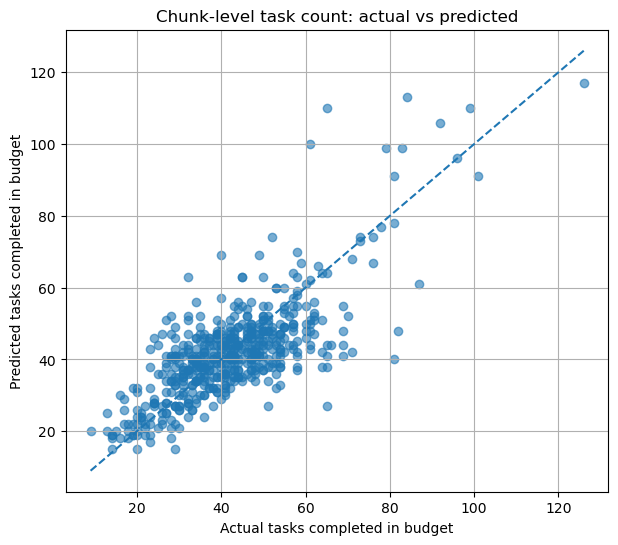

In [63]:
# Scatterplot: actual vs predicted task count per chunk
plot_df = chunk_detail_df.copy()

plt.figure(figsize=(7, 6))
plt.scatter(plot_df["actual_task_count"], plot_df["pred_task_count"], alpha=0.6)
mn = min(plot_df["actual_task_count"].min(), plot_df["pred_task_count"].min())
mx = max(plot_df["actual_task_count"].max(), plot_df["pred_task_count"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual tasks completed in budget")
plt.ylabel("Predicted tasks completed in budget")
plt.title("Chunk-level task count: actual vs predicted")
plt.grid(True)
plt.show()

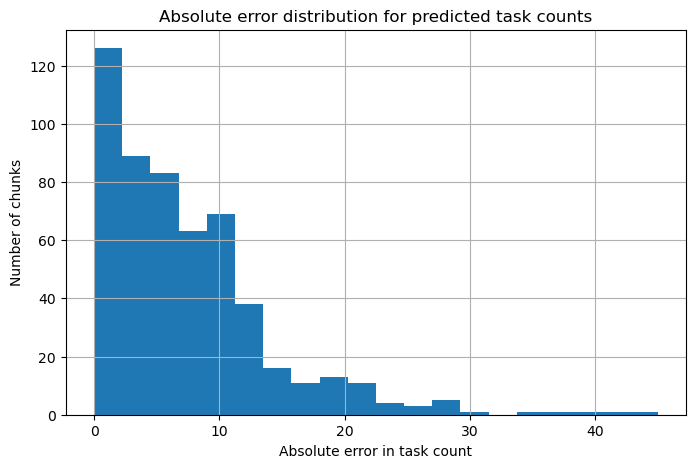

In [64]:
# Histogram of absolute error in predicted task counts
plot_df = chunk_detail_df.copy()
plt.figure(figsize=(8, 5))
plt.hist(plot_df["abs_error_tasks"], bins=20)
plt.xlabel("Absolute error in task count")
plt.ylabel("Number of chunks")
plt.title("Absolute error distribution for predicted task counts")
plt.grid(True)
plt.show()